# GenAI‑Net tutorial: learning IO‑CRN logic circuits 

This notebook is a **hands-on tutorial** for **GenAI‑Net** (the RL4CRN package in this repo).  
We will learn an **input‑output chemical reaction network (IO‑CRN)** that implements a target **3‑input logic function**.

You will see the full pipeline end‑to‑end:

1. **Define a task** (truth table + reward).
2. **Build a template CRN** and a **reaction library**.
3. **Create environments** and **interfaces**.
4. **Instantiate the policy + REINFORCE(+SIL) agent**.
5. **Train** and **inspect best CRNs** (Hall of Fame).


## 0) Setup

### Recommended install (from repo root)

```bash
pip install -e .
```

If you use CUDA, make sure your PyTorch installation matches your GPU + driver.


In [1]:
# --- Path setup: make RL4CRN importable in editable mode ---
# If you installed with `pip install -e .` from the repo root, you can usually skip this cell.
# import sys
# from pathlib import Path

# def add_repo_root_to_path(levels_up: int = 2):
#     here = Path.cwd().resolve()
#     root = here
#     for _ in range(levels_up):
#         root = root.parent
#     sys.path.append(str(root))
#     return root

# REPO_ROOT = add_repo_root_to_path(levels_up=2)
# print("Repo root added to sys.path:", REPO_ROOT)


## 1) Imports

We keep imports grouped by purpose:
- standard scientific Python
- RL4CRN core modules (environment, agent, policy, interfaces)
- CRN construction utilities
- reward functions and plotting helpers


In [2]:
import os
import numpy as np
import torch
from itertools import product
from tqdm import tqdm

# --- RL4CRN core ---
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.parallel_environments import ParallelEnvironments
from RL4CRN.agents.reinforce_agent import REINFORCEAgent
from RL4CRN.policies.add_reaction_by_ordered_index import AddReactionByOrderedIndex
from RL4CRN.policies.add_reaction_by_index import AddReactionByIndex

# --- Interfaces ---
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper

# --- CRN primitives ---
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.iocrns.reaction_library import construct_mass_action_library
from RL4CRN.utils.ic import IC

# --- Rewards + plotting ---
from RL4CRN.rewards.deterministic import dynamic_tracking_error
from RL4CRN.utils.visualizations import plot_truth_table


## 2) Helper functions (to keep the tutorial clean)

These functions turn the long “glue code” into a few clear calls.


In [ ]:
def get_device():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    return device

def build_logic_task(
    logic_fn,
    n_inputs,
    input_values=(0.0, 1.0),
):
    """
    Build a truth-table dataset for a boolean logic function on a binary vector u.

    Args:
        logic_fn: function mapping u (shape [n_inputs]) -> bool
        n_inputs: number of inputs (length of u)
        input_values: iterable of values per input (default {0,1})

    Returns:
        u_list: list of input vectors (float32)
        r_list: list of outputs as shape (1,) float32 arrays
        logic_fn: returned unchanged
    """
    u_list = [
        np.array(u, dtype=np.float32)
        for u in product(input_values, repeat=n_inputs)
    ]
    r_list = [
        np.array([float(bool(logic_fn(u)))], dtype=np.float32)
        for u in u_list
    ]
    return u_list, r_list, logic_fn


def build_template_crn(n_inputs: int, include_dilution: bool = False, solver_settings=None):
    productions, dilutions = [], []
    species_labels = [f"X_{i+1}" for i in range(n_inputs)]

    # input-driven productions: ∅ -> X_i with channel u_i
    for i, s in enumerate(species_labels):
        productions.append(
            MassAction(
                reactant_labels=[],
                product_labels=[s],
                input_channels=[f"u_{i+1}"],
                params=[1.0],
                params_controllability=[True],
            )
        )
        if include_dilution:
            dilutions.append(
                MassAction(
                    reactant_labels=[s],
                    product_labels=[],
                    input_channels=[None],
                    params=[1.0],
                    params_controllability=[True],
                )
            )

    species_labels.append("OUT")  # output species

    crn_template = IOCRN(productions + dilutions, output_labels=["OUT"], solver=solver_settings["algorithm"], rtol=solver_settings["rtol"], atol=solver_settings["atol"])
    crn_template.compile()
    return crn_template, species_labels

def build_library(crn_template: IOCRN, species_labels, order: int = 2):
    library = construct_mass_action_library(species_labels=species_labels, order=order)
    crn_template.set_library_context(library)
    M = len(library.reactions)
    K = library.get_num_parameters()
    masks = {
        "continuous": library.get_parameter_mask(mode="continuous"),
        "discrete": library.get_parameter_mask(mode="discrete"),
        "logit": library.get_logit_mask(),
    }
    return library, M, K, masks

def build_reward_fn(ic: IC, u_list, r_list, time_horizon, w, LARGE_NUMBER=1e4):
    def compute_reward(state: IOCRN):
        x0_list = ic.get_ic(state)
        return dynamic_tracking_error(
            state, u_list, x0_list, time_horizon, r_list, w,
            norm=1, LARGE_NUMBER=LARGE_NUMBER
        )
    return compute_reward

def build_envs(template: IOCRN, max_added_reactions: int, batch_size: int, hall_of_fame_size: int, n_cpus: int, logger=None):
    crn0 = template.clone()
    envs = [Environment(crn0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(batch_size)]
    mult_env = ParallelEnvironments(envs, hall_of_fame_size=hall_of_fame_size, N_CPUs=n_cpus, logger=logger)
    return mult_env

def build_policy(M, K, p, masks, device, *, width=512, depth=3, deep_layer_size=2048,
                 continuous_distribution=None,
                 entropy_weights_per_head=None,
                 ordering=False,
                 target_set_size=None,
                 constraint_strength=float("inf")):
    encoder_attributes = {"hidden_size": width, "num_layers": depth}
    head_attrs = {"hidden_size": width, "num_layers": depth}
    input_influence_head_attributes = {"hidden_size": width, "num_layers": depth}

    if continuous_distribution is None:
        continuous_distribution = {"type": "lognormal_1D"}

    if entropy_weights_per_head is None:
        entropy_weights_per_head = {"structure": 2.0, "continuous": 1.0, "discrete": 0.0, "input_influence": 0.0}

    if ordering:
        if target_set_size is None:
            raise ValueError("target_set_size must be provided when ordering=True.")
        policy = AddReactionByOrderedIndex(
            M, K, p,
            encoder_attributes, deep_layer_size,
            head_attrs, head_attrs, input_influence_head_attributes,
            target_set_size=target_set_size,
            masks=masks,
            allow_input_influence=False,
            device=device,
            continuous_distribution=continuous_distribution,
            entropy_weights_per_head=entropy_weights_per_head,
            combinatorial_bias_enabled=True,
            constraint_strength=constraint_strength,
        )
    else:
        policy = AddReactionByIndex(
            M, K, p,
            encoder_attributes, deep_layer_size,
            head_attrs, head_attrs, input_influence_head_attributes,
            masks=masks,
            allow_input_influence=False,
            device=device,
            continuous_distribution=continuous_distribution,
            entropy_weights_per_head=entropy_weights_per_head,
        )
    return policy

def build_agent(policy, device, *, lr=1e-4, entropy_scheduler=None, risk_scheduler=None, sil_settings=None, logger=None):
    if entropy_scheduler is None:
        entropy_scheduler = {
            "entropy_weight": 1e-3,
            "topk_entropy_weight": 1.0,
            "remainder_entropy_weight": 1.0,
            "entropy_update_coefficient": 1,
            "entropy_schedule": 1000,
            "minimum_entropy_weight": 0.0,
        }
    if risk_scheduler is None:
        risk_scheduler = {"risk": 0.95, "risk_update": 0.0, "max_risk": 1.0, "risk_schedule": 1000}
    if sil_settings is None:
        sil_settings = {"sil_loss_weight": 1.0}

    agent = REINFORCEAgent(
        policy,
        allow_input_influence=False,
        logger=logger,
        learning_rate=lr,
        entropy_scheduler=entropy_scheduler,
        risk_scheduler=risk_scheduler,
        sil_settings=sil_settings,
        device=device,
    )
    return agent

def build_interfaces(library, device, allow_input_influence=False):
    observer = ExplicitObserver(reaction_library=library, allow_input_observation=allow_input_influence)
    tensorizer = ExplicitTensorizer(device=device)
    actuator = LibraryActuator(reaction_library=library)
    stepper = IOCRNStepper()
    return observer, tensorizer, actuator, stepper


## 3) Configure the experiment

Keep *all* experiment knobs in one place.
You can copy this cell and quickly iterate on tasks or training settings.


In [ ]:
CONFIG = {
    # task
    "n_inputs": 3,
    "max_added_reactions": 5,
    "library_order": 2,

    # simulation horizon
    "t_f": 100.0,
    "N_t": 1000,

    # training
    "epochs": 300,
    "render_every": 10,

    # parallelism
    "batch_multiplier": 10,  # batch_size = batch_multiplier * num_cpus
    "hall_of_fame_size": 30,

    # policy network
    "width": 1024,
    "depth": 5,
    "deep_layer_size": 1024 * 10,

    # distributions
    "continuous_distribution": {"type": "lognormal_1D"},

    # entropy & risk
    "entropy_scheduler": {
        "entropy_weight": 1e-3,
        "topk_entropy_weight": 1.0,
        "remainder_entropy_weight": 1.0,
        "entropy_update_coefficient": 1,
        "entropy_schedule": 1000,
        "minimum_entropy_weight": 0.0,
    },
    "risk_scheduler": {"risk": 0.95, "risk_update": 0.0, "max_risk": 1.0, "risk_schedule": 1000},
    "entropy_weights_per_head": {"structure": 2.0, "continuous": 1.0, "discrete": 0.0, "input_influence": 0.0},

    # ordering (optional)
    "ordering": {"enabled": False, "constraint_strength": float("inf")},

    # SIL (optional)
    "sil_settings": {"sil_loss_weight": 1.0},

    # optimizer
    "learning_rate": 1e-4,

    # SOLVER SETTINGS
    "solver": {
        "algorithm": "CVODE", # or LSODA
        "rtol": 1e-10,
        "atol": 1e-10,
    }
}

device = get_device()
num_cpus = os.cpu_count() or 1
batch_size = CONFIG["batch_multiplier"] * num_cpus
print("Num CPUs:", num_cpus)
print("Batch size:", batch_size)


Using device: cuda
Num CPUs: 128
Batch size: 1280


## 4) Define the task (truth table) and reward

We specify:
- input scenarios `u_list` (all 0/1 combinations)
- target outputs `r_list`
- a weighting vector `w` for the tracking metric

In this tutorial we evaluate only the **steady-state output** (weight on the last time step).


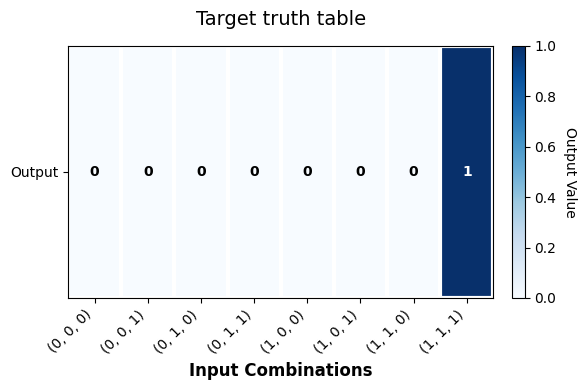

Template CRN compiled. Inputs: 3
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]


In [ ]:
# --- Task ---
u_list, r_list, logic_target = build_logic_task(logic_fn=lambda u: all(u), n_inputs=CONFIG["n_inputs"])
plot_truth_table(u_list, r_list, title="Target truth table")

# --- Time horizon ---
time_horizon = np.linspace(0.0, CONFIG["t_f"], CONFIG["N_t"], dtype=np.float32)

# --- Template CRN + IC ---
crn_template, species_labels = build_template_crn(CONFIG["n_inputs"], include_dilution=False, solver_settings=CONFIG["solver"])
ic = IC(names=species_labels, values=[[0.01 for _ in species_labels]])

# --- Weights: steady state only ---
w = np.zeros((1, CONFIG["N_t"]), dtype=np.float32)
w[:, -1] = 1.0 * CONFIG["N_t"]

compute_reward = build_reward_fn(ic, u_list, r_list, time_horizon, w)
print("Template CRN compiled. Inputs:", crn_template.num_inputs)
print(crn_template)


## 5) Build the reaction library

The library defines the **action space**: at each step the policy chooses a reaction index (and parameters).


In [7]:
library, M, K, masks = build_library(crn_template, species_labels, order=CONFIG["library_order"])
p = crn_template.num_inputs

print("Library size (M):", M)
print("Total library parameters (K):", K)


Library size (M): 211
Total library parameters (K): 211


## 6) Create environments and interfaces

- `Environment` wraps a CRN and the episode logic.
- `ParallelEnvironments` runs a batch in parallel.
- Interfaces define how the agent observes and acts.


In [8]:
mult_env = build_envs(
    template=crn_template,
    max_added_reactions=CONFIG["max_added_reactions"],
    batch_size=batch_size,
    hall_of_fame_size=CONFIG["hall_of_fame_size"],
    n_cpus=num_cpus,
    logger=None,  # keep tutorial self-contained; plug your Comet logger here if desired
)

observer, tensorizer, actuator, stepper = build_interfaces(library, device=device, allow_input_influence=False)
print("Environments ready.")


Environments ready.


## 7) Instantiate policy and agent

You can toggle:
- ordered vs unordered reaction addition
- network size
- entropy/risk schedules
- SIL (self-imitation learning) weight


In [9]:
ordering_cfg = CONFIG["ordering"]
ordering_enabled = ordering_cfg["enabled"]

policy = build_policy(
    M=M, K=K, p=p,
    masks=masks,
    device=device,
    width=CONFIG["width"],
    depth=CONFIG["depth"],
    deep_layer_size=CONFIG["deep_layer_size"],
    continuous_distribution=CONFIG["continuous_distribution"],
    entropy_weights_per_head=CONFIG["entropy_weights_per_head"],
    ordering=ordering_enabled,
    target_set_size=crn_template.num_reactions + CONFIG["max_added_reactions"],
    constraint_strength=ordering_cfg.get("constraint_strength", float("inf")),
)

agent = build_agent(
    policy=policy,
    device=device,
    lr=CONFIG["learning_rate"],
    entropy_scheduler=CONFIG["entropy_scheduler"],
    risk_scheduler=CONFIG["risk_scheduler"],
    sil_settings=CONFIG["sil_settings"],
    logger=None,
)

print("Policy + Agent initialized.")


Policy + Agent initialized.


## 8) Training loop (minimal)

Each epoch:
1. reset environments
2. for `max_added_reactions` steps: observe → act → step
3. evaluate reward (simulation)
4. update agent
5. optionally render

> Tip: start with small `epochs` (e.g. 20) to confirm everything works.


In [10]:
def train(agent, mult_env, epochs, max_steps, render_every=0):
    agent.policy.train()
    for epoch in tqdm(range(epochs), desc="training"):
        mult_env.reset()

        # rollout: add up to max_steps reactions
        for _ in range(max_steps):
            obs = mult_env.observe(observer, tensorizer)
            actions, raw_actions = agent.act(obs, actuator)
            mult_env.step(actions, stepper, raw_actions=raw_actions)

        # evaluate reward by simulation
        rewards = mult_env.get_reward(compute_reward)

        # policy update (with SIL enabled)
        agent.update(
            rewards,
            step_iteration=epoch,
            hof=mult_env.hall_of_fame,
            observer=observer,
            tensorizer=tensorizer,
            stepper=stepper,
            use_sil=True,
            sil_weighting_scheme="uniform",
            sil_batch_size=None,
        )

        if render_every and (epoch % render_every == 0):
            best = float(np.min(rewards))
            med = float(np.median(rewards))
            print(f"[epoch {epoch}] best loss={best:.4g} | median loss={med:.4g}")

train(
    agent=agent,
    mult_env=mult_env,
    epochs=CONFIG["epochs"],
    max_steps=CONFIG["max_added_reactions"],
    render_every=CONFIG["render_every"],
)


training:   0%|          | 1/300 [00:25<2:08:30, 25.79s/it]

[epoch 0] best loss=0.08774 | median loss=1.39


training:   3%|▎         | 9/300 [03:31<1:54:45, 23.66s/it]


[cvHandleFailure, Error: -15] At t = 49.0510942911699, unable to satisfy inequality constraints.



training:   4%|▎         | 11/300 [04:21<1:56:22, 24.16s/it]

...


[cvHandleFailure, Error: -15] At t = 8.61146842141533, unable to satisfy inequality constraints.



training:   7%|▋         | 21/300 [08:25<1:53:30, 24.41s/it]

[epoch 20] best loss=0.01158 | median loss=0.1544


training:   8%|▊         | 23/300 [09:29<1:54:24, 24.78s/it]


KeyboardInterrupt: 

## 9) Inspect results (Hall of Fame)

The Hall of Fame stores the best CRNs found so far (lowest loss).


Hall of Fame size: 30
Best loss: 0.004161832111245666
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_1 + X_3 ----> OUT + X_1;  [MAK(3.5619423389434814)]
OUT + X_1 ----> ∅;  [MAK(7.648763656616211)]
OUT + X_1 ----> X_1 + X_2;  [MAK(1.621941328048706)]
OUT + X_2 ----> OUT + OUT;  [MAK(0.9485584497451782)]
OUT + OUT ----> OUT;  [MAK(1.0423288345336914)]


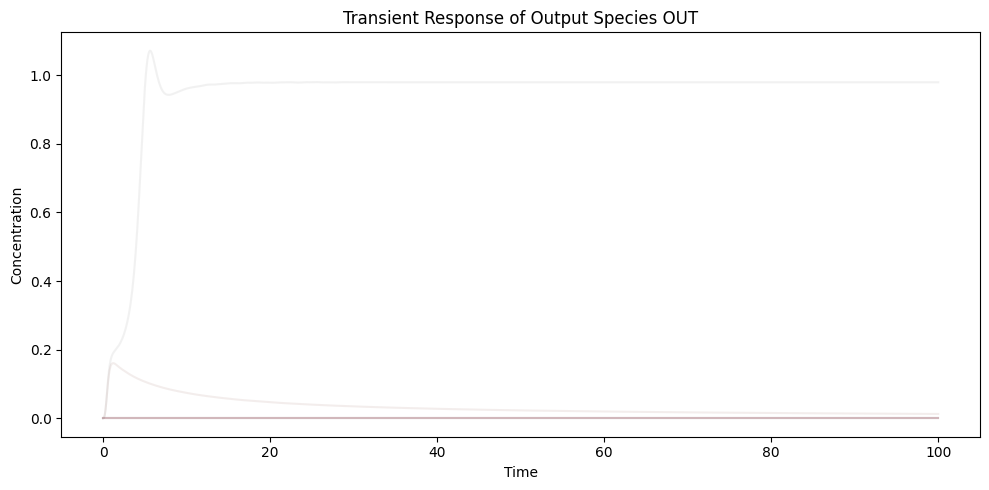

In [16]:
hall_of_fame_crns = [env.state for env in mult_env.hall_of_fame]
print("Hall of Fame size:", len(hall_of_fame_crns))

if hall_of_fame_crns:
    best_crn = min(hall_of_fame_crns, key=lambda c: c.last_task_info.get("reward", np.inf))
    print("Best loss:", best_crn.last_task_info.get("reward", None))
    print(best_crn)
    best_crn.plot_transient_response()


## 10) Saving (optional)

This saves:
- policy weights
- Hall of Fame CRNs (as objects)

Adjust paths to your project conventions.


In [ ]:
SAVE = False
if SAVE:
    import os
    import torch
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    os.makedirs("models", exist_ok=True)
    os.makedirs("hof", exist_ok=True)

    torch.save(agent.policy.state_dict(), f"models/policy_{ts}.pth")
    torch.save(hall_of_fame_crns, f"hof/hall_of_fame_{ts}.pth")
    print("Saved to models/ and hof/.")
